In [1]:
# ============================================================
# PHASE 4a — ARIMA IMPLEMENTATION
# ============================================================

In [2]:
import pandas as pd
import os

# Load the data processed in the previous step
TICKER = "TCS.NS"
df = pd.read_csv(f"data/{TICKER.replace('.','_')}_raw.csv", index_col=0, parse_dates=True)
close = df[['Close']].copy()
close.ffill(inplace=True)
split = int(len(close) * 0.80)

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [4]:
# --- Step 1: Prepare data --- 
# Uses 'close' and 'split' variables from the preprocessing phase
train_arima = close[:split]   # raw Close prices
test_arima  = close[split:]

print(f"ARIMA Train : {len(train_arima)} days")
print(f"ARIMA Test  : {len(test_arima)} days")

ARIMA Train : 1380 days
ARIMA Test  : 346 days


In [5]:
# --- Step 2: Confirm stationarity ---
# Stock prices are usually NOT stationary — we apply differencing (d=1)

result = adfuller(train_arima['Close'])
print(f"ADF p-value (raw)        : {result[1]:.4f} → {'Stationary' if result[1]<0.05 else 'NOT stationary'}")

result_d = adfuller(train_arima['Close'].diff().dropna())
print(f"ADF p-value (differenced): {result_d[1]:.4f} → {'Stationary' if result_d[1]<0.05 else 'NOT stationary'}")
# After 1st differencing, p < 0.05 → d = 1

ADF p-value (raw)        : 0.5823 → NOT stationary
ADF p-value (differenced): 0.0000 → Stationary


In [6]:
# --- Step 3: Auto-select best (p, d, q) using auto_arima ---
print("\nRunning auto_arima to find best parameters...")

auto_model = auto_arima(
    train_arima['Close'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,                     # we confirmed d=1 above
    seasonal=False,          # no seasonal component for daily stock data
    stepwise=True,
    suppress_warnings=True,
    information_criterion='aic',
    error_action='ignore'
)

p, d, q = auto_model.order
print(f"\nBest ARIMA order: ({p}, {d}, {q})")
print(f"AIC Score       : {auto_model.aic():.2f}")



Running auto_arima to find best parameters...

Best ARIMA order: (0, 1, 0)
AIC Score       : 13773.81


In [7]:
# --- Step 4: Fit ARIMA model ---
model = ARIMA(train_arima['Close'], order=(p, d, q))
fitted_model = model.fit()

print(fitted_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1380
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -6886.188
Date:                Sun, 29 Mar 2026   AIC                          13774.376
Time:                        11:22:59   BIC                          13779.606
Sample:                             0   HQIC                         13776.333
                               - 1380                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1273.2703     30.257     42.082      0.000    1213.968    1332.573
Ljung-Box (L1) (Q):                   0.26   Jarque-Bera (JB):               608.13
Prob(Q):                              0.61   Pr

In [8]:
# --- Step 5: Rolling one-step-ahead forecast ---
# This simulates real-world day-by-day prediction.
history      = list(train_arima['Close'])
arima_preds  = []
actual_prices = list(test_arima['Close'])

print("Generating rolling forecasts...")
for i in range(len(test_arima)):
    # Fit on all available history
    temp_model = ARIMA(history, order=(p, d, q))
    temp_fit   = temp_model.fit()

    # Forecast next day
    yhat = temp_fit.forecast(steps=1)[0]
    arima_preds.append(yhat)

    # Add actual value to history for next iteration
    history.append(actual_prices[i])

    if (i + 1) % 50 == 0:
        print(f"  Forecasted {i+1}/{len(test_arima)} days...")

print("Rolling forecast complete.")


Generating rolling forecasts...
  Forecasted 50/346 days...
  Forecasted 100/346 days...
  Forecasted 150/346 days...
  Forecasted 200/346 days...
  Forecasted 250/346 days...
  Forecasted 300/346 days...
Rolling forecast complete.


In [9]:
# --- Step 6: Evaluate ARIMA ---
actual = np.array(actual_prices)
preds  = np.array(arima_preds)

mae  = mean_absolute_error(actual, preds)
rmse = np.sqrt(mean_squared_error(actual, preds))
mape = np.mean(np.abs((actual - preds) / actual)) * 100

print("\n=== ARIMA Performance ===")
print(f"MAE  : ₹{mae:.2f}")
print(f"RMSE : ₹{rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


=== ARIMA Performance ===
MAE  : ₹33.44
RMSE : ₹47.00
MAPE : 0.90%


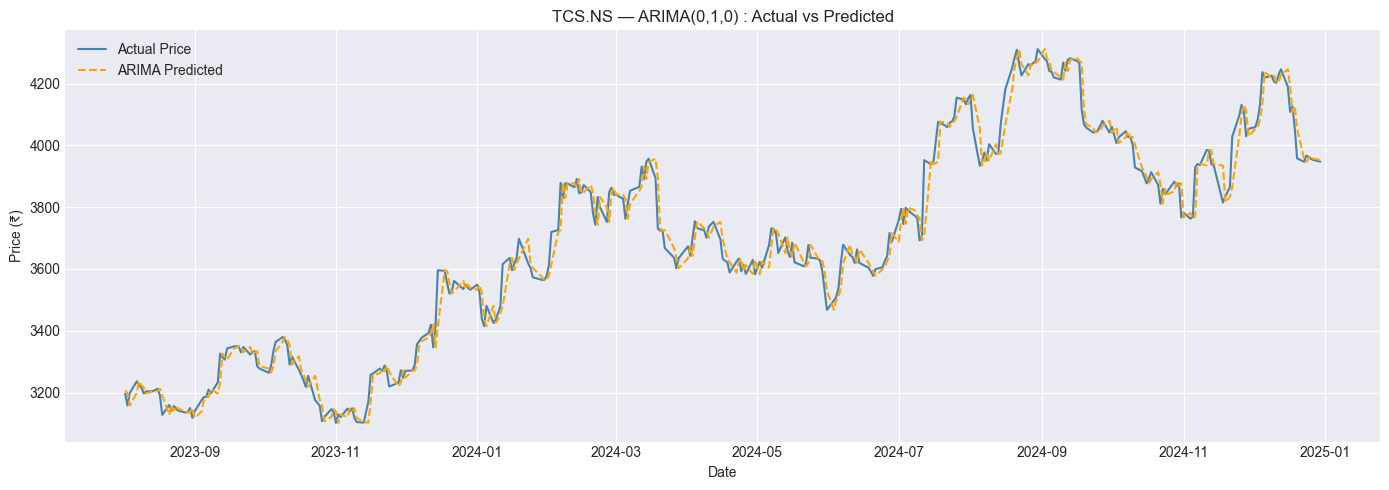

In [10]:
# --- Step 7: Plot Actual vs Predicted ---
plt.figure(figsize=(14, 5))
plt.plot(test_arima.index, actual, color='steelblue',
         label='Actual Price',    linewidth=1.5)
plt.plot(test_arima.index, preds,  color='orange',
         label='ARIMA Predicted', linewidth=1.5, linestyle='--')
plt.title(f'{TICKER} — ARIMA({p},{d},{q}) : Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('plots/08_arima_prediction.png', dpi=150)
plt.show()

In [11]:
# --- Step 8: Save results for comparison with LSTM later ---
arima_results = {
    'model'  : f'ARIMA({p},{d},{q})',
    'MAE'    : round(mae, 2),
    'RMSE'   : round(rmse, 2),
    'MAPE'   : round(mape, 2),
    'preds'  : arima_preds
}
print("\nARIMA results saved. Ready for LSTM implementation.")


ARIMA results saved. Ready for LSTM implementation.


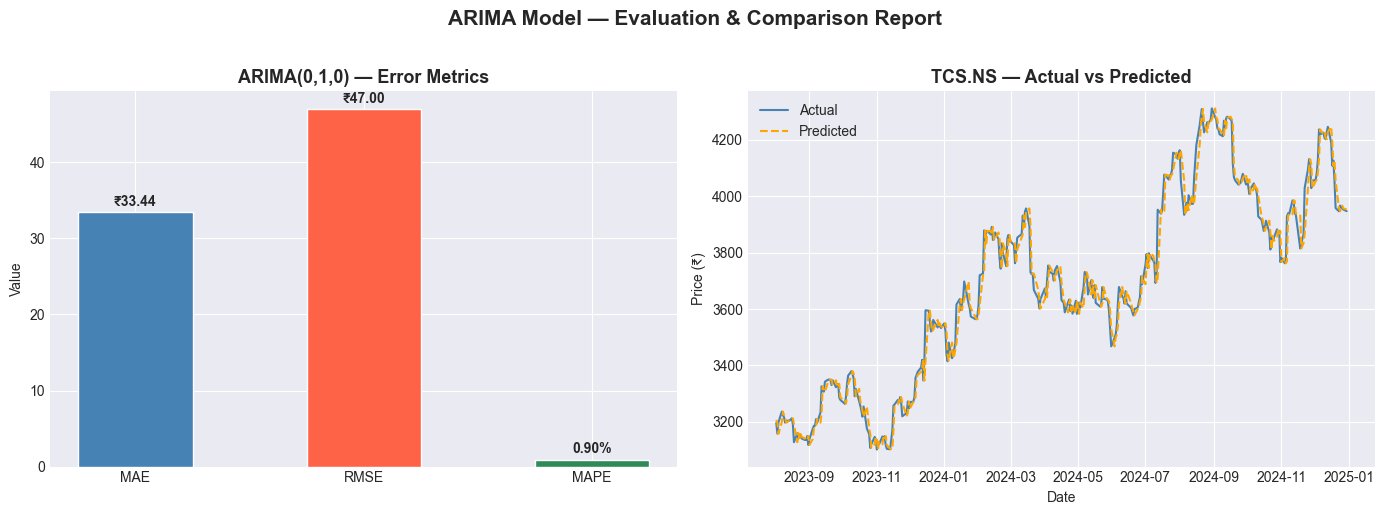


╔══════════════════════════════════════╗
║   ARIMA(0,1,0) Evaluation Report       ║
╠══════════════════════════════════════╣
║  MAE   : ₹33.44                      ║
║  RMSE  : ₹47.00                      ║
║  MAPE  : 0.90                        %║
╚══════════════════════════════════════╝


In [ ]:
# --- Step 9: Model Comparison Report ---
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Bar chart of metrics ---
metrics = ['MAE', 'RMSE', 'MAPE']
values  = [mae, rmse, mape]
colors  = ['steelblue', 'tomato', 'seagreen']

bars = axes[0].bar(metrics, values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title(f'ARIMA({p},{d},{q}) — Error Metrics', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value')

# Annotate bars
for bar, val, metric in zip(bars, values, metrics):
    label = f'₹{val:.2f}' if metric != 'MAPE' else f'{val:.2f}%'
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(values)*0.01,
                 label, ha='center', va='bottom', fontweight='bold')

# --- Right: Actual vs Predicted ---
axes[1].plot(test_arima.index, actual, color='steelblue',
             label='Actual',    linewidth=1.5)
axes[1].plot(test_arima.index, preds,  color='orange',
             label='Predicted', linewidth=1.5, linestyle='--')
axes[1].set_title(f'{TICKER} — Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (₹)')
axes[1].legend()

plt.suptitle('ARIMA Model — Evaluation & Comparison Report',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/09_arima_evaluation_report.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print summary table ---
print("\n╔══════════════════════════════════════╗")
print(f"║   ARIMA({p},{d},{q}) Evaluation Report ║")
print("╠══════════════════════════════════════╣")
print(f"║  MAE   : ₹{mae:<27.2f}║")
print(f"║  RMSE  : ₹{rmse:<27.2f}║")
print(f"║  MAPE  : {mape:<28.2f}%║")
print("╚══════════════════════════════════════╝")